# init

In [1]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
# import ipynbname
# NOTEBOOK_PATH = ipynbname.path()
# PARENT_DIR = NOTEBOOK_PATH.parent.parent  # parent of the notebook's directory
# print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
# print("PARENT_DIR: " + str(PARENT_DIR))
#OPTION 2: Manually set PARENT_DIR if needed
PARENT_DIR = "/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR"
DATA_DIR = "/export/general/pooledData/Jackson/repo_data/"
figSaveDir = os.path.join(PARENT_DIR, "figurePanels", "Fig5")
PDF_export_active = False

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()

#IMPORTANT Load the manuscript functions
import js_manuscript_final as jsm

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
# path = os.path.join(PARENT_DIR, "js_manuscript_final.py")
# spec = importlib.util.spec_from_file_location("jsm", path)
# jsm = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(jsm)
# print(jsm.__file__)

#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

# <font size="5">Load the exported example ROIs back out of the repo files

In [2]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# This is the only cell a repo-only rebuild of the figure needs — no pooled dataset, no
# sled_reImport_aligned_trace_data. The repo-facing notebooks (e.g. fig5.ipynb) call the identical
# function as jsm.load_all_grouped_aligned_traces_split with the same arguments.
savePath = os.path.join(DATA_DIR,'examples','fig5_indiv_examples')  # directory holding the '_meta' and part files
saveName = 'fig5_indiv_examples'   # same base name passed to save_all_grouped_aligned_traces_split
groups = None                      # None -> every group saved; or list, e.g. ['goCue']
align_datas = None                 # None -> every align_data saved; or list, e.g. ['allTC_dffbc_decon_sp_events_MatchDx2Sx1']
anms = None                        # None -> every animal saved; or list of animal IDs
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
ROI_idxs = None                    # None -> all example ROIs; or list of ROI indices to keep
trace_types = None                 # None -> every trace_type saved; or list of trace_types to keep
extension = '.pkl'              # '.pkl.gz' | '.pkl.xz' | '.pkl.bz2' | '.pkl'  (extension used when the files were written)
restore_float_dtype = 'float32'    # None -> keep the stored dtype; or 'float32' to cast float16 traces back up
verbose = True                     # True | False  (prints each part file loaded)
all_grouped_aligned_traces_repo, cueInfo_repo, summaryInfo_repo = jsm.load_all_grouped_aligned_traces_split(
    savePath, saveName, groups=groups, align_datas=align_datas, anms=anms, ROI_type_keys=ROI_type_keys, 
    ROI_scores=ROI_scores, ROI_idxs=ROI_idxs, trace_types=trace_types, extension=extension, restore_float_dtype=restore_float_dtype, verbose=verbose)

# The trace_types actually present in the loaded repo data. The re-plot cell below pins
# figParams['trialGrouping'] to this, so what gets plotted can never drift from what was exported.
repo_trace_types = []
for g in all_grouped_aligned_traces_repo:
    for ad in all_grouped_aligned_traces_repo[g]['grouped_aligned_traces']:
        traces = all_grouped_aligned_traces_repo[g]['grouped_aligned_traces'][ad].get('aligned_traces',{})
        for a in traces:
            for rt in traces[a]:
                for sc in traces[a][rt]:
                    for ri in traces[a][rt][sc]:
                        for t in traces[a][rt][sc][ri]:
                            if t not in repo_trace_types:
                                repo_trace_types.append(t)
# 'bySess_byTtype' only rides along as session support, so it is not a trace_type to plot on its own.
# These are STORED branch names: a figure trace_type of 'preShiftOnly_byTtype' reads 'byPrePost_byTtype'.
repo_trace_types = [t for t in repo_trace_types if t != 'bySess_byTtype'] or repo_trace_types
print(f"trace_types (stored branches) available in the repo data: {repo_trace_types}")

load_all_grouped_aligned_traces_split: savePath='/export/general/pooledData/Jackson/repo_data/examples/fig5_indiv_examples' saveName='fig5_indiv_examples' groups=None align_datas=None anms=None ROI_type_keys=None ROI_scores=None ROI_idxs=None trace_types=None
  + loaded fig5_indiv_examples_meta.pkl  (3.06 MB)
  = cueInfo: loaded from metadata file | summaryInfo: loaded from metadata file
  + loaded fig5_indiv_examples_traces_cTimes_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002121774_dendrites_1_ROI39.pkl  (0.42 MB)
  + loaded fig5_indiv_examples_traces_cTimes_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002213982_somas_1_ROI20.pkl  (0.38 MB)
  = ['cTimes']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002121774']['dendrites'][1][39]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
  = ['cTimes']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002213982']['somas'][1][20]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
trace_types (stored branches) available in the repo data: ['b

In [3]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# Small manifest of the per-example scalars trial_alignments_byROI_pages needs beyond the traces
# themselves (identifying indices + cosmetic page/cluster label text) — written by the export cell in
# fig5_indiv_examples.ipynb, loaded here so this repo-only notebook never needs ROI_clustering (a
# clustering-run object that never ships to the repo).
import json
manifest_path = os.path.join(savePath, saveName+'_ROI_manifest.json')  # written by the export cell in fig5_indiv_examples.ipynb
with open(manifest_path,'r') as f:
    ROI_manifest = json.load(f)
print(f"Loaded {len(ROI_manifest)} example ROI(s) from {manifest_path}")

Loaded 2 example ROI(s) from /export/general/pooledData/Jackson/repo_data/examples/fig5_indiv_examples/fig5_indiv_examples_ROI_manifest.json


In [4]:
figParams = {}
figParams['cueInfo'] = cueInfo_repo
group = 'cTimes'
group_labels = ['AllTraceTypes_SDNorm']
trialGroupings = ['postShiftOnly_byTtype']
trialGrouping_labels = ['PostShift']
plotSets = ["CR,MER_FC,MER_FA"]
figParams['export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] 
figParams['export_align_data_labels'] = ['sp_eventD2S1'] 
figParams['export_ttypes'] = ['CR','MER_FC'] 
figParams['scaling_ttypes'] = ['CR','MER_FC']

########################################################
figParams['plot_stat'] = 'summaryStats'
tg = 0
trialGrouping = trialGroupings[tg]
trialGrouping_label = trialGrouping_labels[0]
ps = plotSets[0]
a = 0
align_data = figParams['export_align_data'][a]
figParams['align_data'] = align_data
figParams['align_data_label'] = figParams['export_align_data_labels'][a]
figParams['formatMode'] = 'vert'
figParams['examples_group'] = group
figParams['trialGrouping'] = trialGrouping
figParams['trial_group_label'] = trialGrouping_labels[tg]
figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.01
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['addSpacers'] = True
figParams['dayLabels'] = True
figParams['sess_cmap'] = 'tab10'
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = [1]                              # 1,-1,0
figParams['shiftDay_nTrials'] = 100
figParams['shiftTrial_color'] = (1,0,0)
figParams['shiftTrial_lineStyle'] = ':'
figParams['shiftTrial_lineWidth'] = 0.5
figParams['shiftTrial_alpha'] = 0.3
figParams['yTicksOn'] = False
figParams['match_trial_counts'] = True
figParams['match_trial_ticks'] = 50
figParams['minRepeats_forYLim'] = 40 #to contribute to max/min caCLs
figParams['plotScalar']=0
figParams['scale_font'] = 10
figParams['legendFontsize'] = 6
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 0.5

aaronCmap = {}
aaronCmap['type'] = 'smooth_diverging'
aaronCmap['cmap2'] = "gray"
aaronCmap['cmap1'] = "inferno"
aaronCmap['cutoff'] = 0.85
aaronCmap['center_width'] = 0.3
aaronCmap['minVal'] = 0.5
aaronCmap['maxVal'] = 0.9

figParams['cmap'] = aaronCmap
figParams['nan_color'] = (0.3,0.3,0.3)
figParams['horzScalar'] = 10
figParams['horzScalar_im'] = 10
figParams['horzScalar_zoom'] = 10
figParams['vertScalar'] = 3
figParams['vertScalar_im'] = 3
figParams['vertScalar_zoom'] = 3

figParams['horz_scale']=1
figParams['horz_scale_label']=" s"
figParams['horz_scale_loc']='TL'
figParams['vert_scale_loc']='TL'

##############################
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['length_s'] = 1
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['height_per'] = 0.4
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.4
figParams['plot_scaleBar']['horzAdjust']=0.1
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
##############################
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.3
figParams['im_scaleBar']['vertUnit'] = ''
figParams['im_scaleBar']['horzUnit'] = 's'
figParams['im_scaleBar']['manual_height'] = 100
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.2
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False

##############################
figParams['nan_empty_trials'] = True
figParams['plot_error'] = True

figParams['plot_key_main'] = 'boot_mean'
figParams['plot_key_error_pos'] = 'boot_std' #'sem'
figParams['plot_key_error_neg'] = 'boot_std' #'sem'
figParams['plot_key_label'] = "Trial Bootstrap\nMean (STD)"
figParams['plot_label'] = "TrialBootMeanSTD"

figParams['imshow_lineColor'] = (0,0,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['nSpacers'] = 3
figParams['endSpacer'] = False
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000
##############################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
##############################
figParams['vertUpperPlotBuffer'] = 0.02
figParams['vertLowerPlotBuffer'] = 0.01
figParams['manual_plotLims'] = False
figParams['manual_imCont'] = False
figParams['highImCont'] = {}
figParams['lowImCont'] = {}
figParams['highNormImCont'] = {}
figParams['lowNormImCont'] = {}
figParams['highDeltaImCont'] = {}
figParams['highROIImCont'] = {}
figParams['lowROIImCont'] = {}
figParams[align_data] = {}
figParams[align_data]['highROIImCont'] = {}
figParams[align_data]['lowROIImCont'] = {}
figParams[align_data]['nan_empty_trials'] = False
figParams[align_data]['revert_mask'] = True
figParams[align_data]['maxPer'] = 100
figParams[align_data]['highROIImCont']['dendrites'] = 0.2
figParams[align_data]['lowROIImCont']['dendrites'] = 0
figParams[align_data]['highROIImCont']['somas'] = 0.1
figParams[align_data]['lowROIImCont']['somas'] = 0
figParams['highCont'] = 0.9
figParams['minPer'] = 0
figParams['lowCont'] = 1
figParams['highImCont']['dendrites'] = []
figParams['lowImCont']['dendrites'] = []
figParams['highNormImCont']['dendrites'] = []
figParams['lowNormImCont']['dendrites'] = []
figParams['highDeltaImCont']['dendrites'] = []
figParams['highImCont']['somas'] = []
figParams['lowImCont']['somas'] = []
figParams['highNormImCont']['somas'] = []
figParams['lowNormImCont']['somas'] = []
figParams['highDeltaImCont']['somas'] = []

figParams['highImCont']['dendrites'].append(0.005)
figParams['lowImCont']['dendrites'].append(0)
figParams['highNormImCont']['dendrites'].append(0.8)
figParams['lowNormImCont']['dendrites'].append(0)
figParams['highDeltaImCont']['dendrites'].append(0.1)
figParams['highImCont']['somas'].append(0.005)
figParams['lowImCont']['somas'].append(0)
figParams['highNormImCont']['somas'].append(0.8)
figParams['lowNormImCont']['somas'].append(0)
figParams['highDeltaImCont']['somas'].append(0.1)
figParams['expanding_lineColor'] = (0.5,0.5,0.5)
figParams['expanding_lineStyle'] = '-'
figParams['expanding_lineWidth'] = 0.5
figParams['expanding_lineAlpha'] = 0.5
figParams['expanding_lineColor'] = (0.5,1,0)


figParams['nan_empty_trials'] = figParams[align_data]['nan_empty_trials']
figParams['revert_mask'] = figParams[align_data]['revert_mask']
figParams['maxPer'] = figParams[align_data]['maxPer']
figParams['highROIImCont'] = figParams[align_data]['highROIImCont']
figParams['lowROIImCont'] = figParams[align_data]['lowROIImCont']

figParams['constrained_layout'] = False
figParams['dayLabels'] = True
figParams['clean'] = True
figParams['facecolor'] = 'none'
figParams['facecolor'] = (1,1,1)
figParams['yTicksOn']= False
figParams['legendLoc'] = 'lower left'
figParams['legendBboxToAnchor'] = (0, 1)

figParams['lineWidth'] = 0.5


NameError: name 'zoom_s' is not defined

In [ ]:
figName = 'Fig5_examples.pdf'
figSaveDir = "/export/general/pooledData/Jackson/JS_figsPanels/Fig5"
figParams['plot_figSummary_label'] = ps
figParams['export_ttypes'] = ['CR','MER_FC','MER_FA'] 
figParams['export_ttype_colors'] = [(0,0,1),(1,0.5,0),(0.5,0.5,0.5)]
figParams['scaling_be'] = ['preShift','postShift']

figParams['scaling_ttypes'] = ['CR','MER_FC','MER_FA']
figParams['export_ttypes'] = ['CR','MER_FC'] 
figParams['export_ttype_colors'] = [(0,0,1),(1,0.5,0)]
figParams['scaling_ttypes'] = ['CR','MER_FC']
figParams['autoScale_ttypes'] = figParams['scaling_ttypes']
figParams['autoScale_be_ttypes'] = figParams['scaling_ttypes']
figParams['horzScalar_im_zoom'] = 1.5
figParams['vertScalar_im_zoom'] = 1
figParams['wspace'] = 0.03
figParams['hspace'] = 0
figParams['facecolor'] = 'none'
figParams['facecolor'] = (1,1,1)
figParams['max_nTrials_display'] = 0
figParams['export_byPrePost_ttype_colors'] = {}
figParams['export_byPrePost_ttype_colors']['preShift'] = figParams['export_ttype_colors']
figParams['export_byPrePost_ttype_colors']['postShift'] = figParams['export_ttype_colors']
if 'ShiftOnly' in trialGrouping:
    figParams['addSpacers'] = False
    figParams['export_byPrePost_ttype_colors']['preShift'] = figParams['export_ttype_colors']
    figParams['export_byPrePost_ttype_colors']['postShift'] = figParams['export_ttype_colors']

figParams['preview_figs'] = False
figParams['close_all_figs'] = False
saveFigs = PDF_export_active
verbose =True
figParams['manual_plotLims'] = False
figParams[align_data]['highROIImCont']['dendrites'] = 0.1
figParams[align_data]['lowROIImCont']['dendrites'] = 0
figParams[align_data]['highROIImCont']['somas'] = 0.08
figParams[align_data]['lowROIImCont']['somas'] = 0
figSaveDir = "/export/general/pooledData/Jackson/JS_figsPanels/Fig5"

with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    for e,entry in enumerate(ROI_manifest):

        pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
            figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
            entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
            entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)


# Figure 5 Licking data

In [ ]:
savePath = os.path.join(DATA_DIR,'traceAlignments','fig5_licking')  # existing directory to write the part files into
saveName = 'fig5_licking'   # base name; '_meta' / '_<key>_<ROI_type>_<score>' suffixes are appended
extension = '.pkl'                 # '.pkl' | '.p'
verbose = True
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
big_keys = None                    # None -> every big key saved; [] -> metadata only
clusterList = None                 # None/[] -> all clusters; or list of cluster indices
trialGroupings = None                 # None -> all trial groupings; or list of trial grouping indices
ROI_clustering, cueInfo = jsm.load_ROI_clustering_reduced_split(
    savePath, saveName, ROI_type_keys=ROI_type_keys, ROI_scores=ROI_scores, big_keys=big_keys, clusterList=clusterList, trialGroupings=trialGroupings, extension=extension, verbose=verbose)


In [ ]:
close_all_figs = False
figSubDir = []
zoom_s = -4
export_align_data = ['licks_per_s_Dx2_Sx1']
export_groups = ['cTimes']
setLabel = 'Post_CR_CA_AP_OverlaySplit_FIG'
batchID = 'fig5_licking'

figParams = {}

figParams['clean'] = True
####################################################################################################################################################################################
figParams['scaling_ttypes'] = ['CR','MER','MER_postCont1R','MER_FC','MER_FA','MER_AR','MER_AL','MER_AN']  
figParams['scaling_be'] = ['preShift','postShift']  
##############################
figParams['scale_font'] = 10
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 1
figParams['cmap'] = 'inferno'
figParams['imshow_lineColor'] = (0,1,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000

figParams['ylim_adjust'] = [0,0]

figParams['traceSet_clusterGrid'] = True
# figParams['traceSet_split_ttypes'] = True
# figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_fillNaNs'] = False

figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.03
figParams['cueInfo'] = cueInfo

figParams['plot_stat_byROI'] = 'data'
figParams['plot_data_label_byROI'] = 'ROI Bootstrap Mean'
figParams['plot_stat'] = 'summaryStats'  # summaryStats, summaryStats_ttype_norm, summaryStats_ROI_norm, summaryStats_noExcl, summaryStats_noExcl_ttype_norm, summaryStats_noExcl_ROI_norm
figParams['plot_data_label'] = ''

figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_label_full'] = "Post Shift\nCluster Boot Mean"
figParams['plot_data_axis_label'] = 'Post Shift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_axis_label1'] = 'Post Shift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_error_pos'] = 'boot_std' #'sem'
figParams['plot_data_error_neg'] = 'boot_std' #'sem'
figParams['plot_data_error_pos1'] = 'boot_std' #'sem'
figParams['plot_data_error_neg1'] = 'boot_std' #'sem'

figParams['traceSet_imshow_lineColor'] = (1,1,1)
figParams['traceSet_imshow_lineWidth'] = 1
figParams['traceSet_imshow_ytick_rotation'] = 0
figParams['traceSet_imshow_ytick_verticalalignment'] = 'center'
figParams['traceSet_imshow_ytick_horizontalalignment'] = 'right'
figParams['traceSet_plot_lineWidth'] = 1
figParams['traceSet_plot_line_alpha'] = 1
figParams['traceSet_plot_error_alpha'] = 0.3
figParams['traceSet_plot_markerSize'] = 3
figParams['traceSet_plot_full_legend'] = False
figParams['traceSet_plot_ytick_rotation'] = 0
figParams['traceSet_plot_ytick_verticalalignment'] = 'center'
figParams['traceSet_plot_ytick_horizontalalignment'] = 'right'
figParams['traceSet_alpha'] = 0.5
figParams['traceSet_fontSize'] = 12
figParams['traceSet_addSpacers'] = True
figParams['traceSet_matchCont'] = True
figParams['traceSet_cmap'] = 'inferno'
figParams['nan_color'] = (0.2,0.2,0.2)

figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['length_s'] = 1
print(figParams['plot_scaleBar']['length_s'])
figParams['plot_scaleBar']['height_per'] = 0.5
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.2
figParams['plot_scaleBar']['horzAdjust']=0.025
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
figParams['plot_scaleBar']['horzUnit'] = 's'
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.4
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.3
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']['vertUnit'] = 'Anm.'
figParams['im_scaleBar']['horzUnit'] = 's'

figParams['global_im_contrast'] = True
figParams['ROI_type_im_contrast'] = False
figParams['manual_im_contrast'] = False
figParams['global_plot_contrast'] = True
figParams['ROI_type_plot_contrast'] = False
figParams['manual_plot_contrast'] = False
figParams['traceSet_aspect'] = False
figParams['traceSet_hscalar'] = 1
figParams['traceSet_vscalar'] = 1
figParams['suptitle_margin'] = 1

##############################
figParams['clustered_data'] = 'mean'  # 'mean', 'var'
####################################################################################################################################################################################
print("Starting Set: "+str(setLabel))
figParams['traceSet_overlay'] = False

figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
ROI_type_key = 'dendrites'
ROI_score = 1
figParams['export_traceSets'] = {}
paramAvail = False

figParams['traceSet_overlay'] = True
trialGrouping = 'byPrePost_byTtype'
###################################
figParams['traceSet_split_ttypes'] = True
figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_overlay'] = True
figParams['traceSet_trace_plotScalar'] = [1,1,1]
figParams['traceSet_export_align_data'] = ['licks_per_s_Dx2_Sx1']  # 'allTC_dffbc', 'allTC_dffbc_decon',  'allTC_dffbc_decon_sp'
figParams['traceSet_export_align_data_label'] = ['Licks s-1']               # 'DFF BC',      'DFF BC Decon Den',   'Decon SP'
figParams['traceSet_export_align_data_scaleBar_label'] = ['Licks s-1']
###################################
paramAvail = True
cg = 0
figParams['export_traceSets'][cg] = {}
###################################
ts = 'LeftLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Left Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Left Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [1]
figParams['export_traceSets'][cg][ts]['colors'] = [[0,0,1]]
ts = 'RightLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Right Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Right Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0]
figParams['export_traceSets'][cg][ts]['colors'] = [[0,0,1]]

###################################
paramAvail = True
cg = 1
figParams['export_traceSets'][cg] = {}
###################################
ts = 'LeftLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Left Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Left Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['MER_FC']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [1]
figParams['export_traceSets'][cg][ts]['colors'] = [[1,0.5,0]]
ts = 'RightLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Right Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Right Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['MER_FC']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0]
figParams['export_traceSets'][cg][ts]['colors'] = [[1,0.5,0]]
###################################

###################################
paramAvail = True
cg = 2
figParams['export_traceSets'][cg] = {}
###################################
ts = 'LeftLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Left Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Left Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['MER_FA']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [1]
figParams['export_traceSets'][cg][ts]['colors'] = [[0.5,0.5,0.5]]
ts = 'RightLicks_postShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Right Licks postShift'
figParams['export_traceSets'][cg][ts]['overlayColor'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Right Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'postShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['MER_FA']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0]
figParams['export_traceSets'][cg][ts]['colors'] = [[0.5,0.5,0.5]]
###################################
a=0
figParams['manual_contrasts'] = {}
############################################################################################################################################

figParams['globalCont'] = True
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = ['licks']                              # 1,-1,0
figParams['traceSet_clusterGrid'] = True
figParams['traceSet_addClusterLabels'] = True
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_byROI'] = 'boot_mean'
figParams['plot_data_errors'] = True
figParams['plot_data_error_pos'] = 'boot_std'
figParams['plot_data_error_neg'] = 'boot_std'
print(figParams['plot_scaleBar']['length_s'])
############################################################################################################################################
group = 'cTimes'
figParams['trialGrouping'] = trialGrouping
figName = figParams['trialGrouping']+'_'+group+"_"+setLabel+"_LicksPerSec_MatchDx2Sx1"
figParams['traceSet_group'] = group
figParams['traceSet_image_minPer'] = 0
figParams['traceSet_image_maxPer'] = 98
figParams['traceSet_minCont'] = [0,0,0]
figParams['traceSet_maxCont'] = [1,1,1]
figName = figName+figParams['plot_data_label']
jsm.ROI_cluster_traceSets(figSaveDir,figSubDir,batchID,figName,ROI_clustering,figParams,zoom,close_all_figs)


In [ ]:
#IMPORTANT Load the masterData dictionary, preferably from the data repo reduced file size versions
masterData = jsm.masterData_loading(DATA_DIR)
# mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
# mdTitle = 'allSlim3'
# masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))

#General params
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]
anms = list(masterData.keys())


In [ ]:
dffKey = 'impulse_trace'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
dffKeys = ['impulse_trace']#['consensus_NMFtc_dff_bc_decon_sp', 'consensus_NMFtc_dff_bc', 'impulse_trace']
maskKey = 'trace_mask'

factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = [-3.6,3.6]
allAnmParams = jsm.get_allAnmParams2(masterData, anms, frs, factors, Z, phases2, dffKeys, maskKey=maskKey, windowSize = windowSize)


In [ ]:
dffKey = 'impulse_trace'
thrsh = 0.05
minTrials = 5
anatKeys = ['dendrites', 'somas']

aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

# preCalc megaTsep and CDs

In [ ]:
shiftAnms = {}
for anat in anatKeys:
    shiftAnms[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays
            sessions = np.unique(tracker[anatMask,0])
            if 0 in sessions:
                shiftAnms[anat].append(anm)
                print(f'{anm} {anat} {sessions} SHIFT DAY')


In [ ]:
iAnms = {}
aAnms = {}
minTrials = 10
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
print(iAnms)

In [5]:
iAnms2 = {}
aAnms2 = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms2)

NameError: name 'anatKeys' is not defined

In [6]:
bothAnms = {}
bothANDshiftAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    anms3 = shiftAnms[anat]
    common_animals = set(anms1) & set(anms2) & set(anms3)
    count = len(common_animals)

    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'SHIFT Day {len(anms3)}',\
          f'Both {np.sum(np.isin(anms1, anms2))}', f'BOTH AND SHIFT Day {count}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
    bothANDshiftAnms[anat] = common_animals

print(bothAnms)
print(bothANDshiftAnms)

NameError: name 'anatKeys' is not defined

In [7]:
for ak, anat in enumerate(anatKeys):
    akSum = 0
    for anm in bothAnms[anat]:
        akSum+=np.sum(keepRoisDS[anat][anm])
    print(anat, akSum)

NameError: name 'anatKeys' is not defined

In [12]:
iAnms = {}
aAnms = {}
minTrials = 5
percs = {}
counts = {'post_ALL':0,'post_CL':0,'post_CR':0,'post_MER':0,'post_CA':0,'post_AP':0}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    percs[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            merl_me = allAnmParams[anm]['MER-L_ME']
            merl_nome = allAnmParams[anm]['MER-L_noME']
            
            slN = allAnmParams[anm]['sl_nHits']
            
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]


            pAll = np.sum(posttkr[:,2]==0)+np.sum(posttkr[:,2]==1)+np.sum(posttkr[:,2]==5)+np.sum(posttkr[:,2]==6)
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            pCA = np.sum(postAR)
            pAP = np.sum(postLN)
            pHit = np.sum(np.logical_and(slN[postAnatMask]>0, postME))
            pMiss = np.sum(np.logical_and(slN[postAnatMask]==0, postME))

            counts['post_ALL']+=pAll
            counts['post_CL']+=pCL
            counts['post_CR']+=pCR
            counts['post_MER']+=pMER
            counts['post_CA']+=pCA
            counts['post_AP']+=pAP

            
            hitP = np.sum(pHit)/np.sum(postME)
            missP = np.sum(pMiss)/np.sum(postME)

            MERL_ME = np.sum(merl_me[postMask])
            MERL_noME = np.sum(merl_nome[postMask])
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials and MERL_ME>minTrials and MERL_noME>minTrials:# and pHit>minTrials and pMiss>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
                        percs[anat].append([hitP,missP])
print(iAnms)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213908 53 21 336
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213908', 'B00002213932', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213908', 'B00002213997', 'B00002213999', 'B00002214001']}


/tmp/ipykernel_661714/570402471.py:72: RuntimeWarning: invalid value encountered in scalar divide
  hitP = np.sum(pHit)/np.sum(postME)
/tmp/ipykernel_661714/570402471.py:73: RuntimeWarning: invalid value encountered in scalar divide
  missP = np.sum(pMiss)/np.sum(postME)


In [13]:
counts

{'post_ALL': 18039,
 'post_CL': 5607,
 'post_CR': 6795,
 'post_MER': 4010,
 'post_CA': 2169,
 'post_AP': 1841}

In [14]:
total = 0
for key in counts.keys():
    if not 'ALL' in key:
        total+=counts[key]
print(total)

20422


In [15]:

psWindow = [-3.6,3.6]
useDS = True
#anmsToUse = iAnms
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
nTriToDraw = 50
binary = False
giveAll = True

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre','post']
pLabels = ['pre','post']
mods = ['errGO', 'errCT', 'errSL']#, 'errLL']
alignTimes = ['goCues','cTimes','secondLick']#,'lastLick']
mods = [ 'errCT']#, 'errLL']
alignTimes = ['cTimes']#,'lastLick']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]
    
if giveAll:
    nTri = 10
else:
    nTri = 4
somaEmpty = np.empty([nTri, somaTime, nSoma, nBoot]).astype('float32')
dendEmpty = np.empty([nTri, dendTime, nDend, nBoot]).astype('float32')
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])

## important loop
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH_ALT(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, keepRoisFull, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, nTriToDraw, binary, useDS, giveAll)
            for phase in phases:
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase].astype('float32')
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase].astype('float32')

  0%|          | 0/10000 [00:00<?, ?it/s]

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2980: RuntimeWarning: Mean of empty slice
  SLR = np.nanmean(psTsep[SLRt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2985: RuntimeWarning: Mean of empty slice
  SLL = np.nanmean(psTsep[SLLt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:3012: RuntimeWarning: Mean of empty slice
  DE = np.nanmean(psTsep[DEt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:3036: RuntimeWarning: Mean of empty slice
  AL_ME = np.nanmean(psTsep[al_MEt,:,:], axis = 0)


In [16]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(bothAnms[anat]))
    print(megaTsepsHH['post1']['errCT'][anat].shape)
    print((1/frs[ak])*factors[ak])
    print('')

dendrites 10
(10, 32, 167, 10000)
0.22421524663677128

somas 8
(10, 34, 179, 10000)
0.21929824561403508



# paper text quants

In [17]:
### both ports touched on contact lick

allTrialDoubles = []
CADoubles = []

for anm in anms:

    anmParams = allAnmParams[anm]
    anmData = masterData[anm]
    bpodLicks = jsm.get_lickTimes(anmData['behavior'])
    cTimes = anmParams['cTimes']
    attemptedTrials = np.isfinite(cTimes)
    goCues = anmParams['goCues']
    cLicks = anmParams['cLicks']
    tracker = anmParams['tracker']
    me = anmParams['me']
    slSide = anmParams['slSideTracking']
    
    contacts = []
    for t in range(cLicks.shape[0]):
        if attemptedTrials[t]:
            tLickTime = cLicks[t,:,3]+goCues[t]
            tBpod = bpodLicks[:,:,t]
        
            mask = (np.nanmin(tLickTime)<tBpod[:,0])&(tBpod[:,0]<np.nanmax(tLickTime))
            
            nPortsContacted = len(np.unique(tBpod[mask,1]))
            contacts.append(nPortsContacted)
        else:
            contacts.append(np.NaN)
    
    contacts = np.hstack(contacts)
    allTrialDoubles.append(np.sum(contacts==2)/np.sum(attemptedTrials))
    
    caMask = (me)&(tracker[:,2]==5)&(slSide==0)
    CADoubles.append(np.sum(contacts[caMask]==2)/np.sum(caMask))
    
print('any trial: ', f'{np.median(allTrialDoubles)*100:.03f}%')
print('ca: ', f'{np.median(CADoubles)*100:.03f}%')

/tmp/ipykernel_661714/3192881762.py:25: RuntimeWarning: All-NaN slice encountered
  mask = (np.nanmin(tLickTime)<tBpod[:,0])&(tBpod[:,0]<np.nanmax(tLickTime))


any trial:  1.517%
ca:  4.073%


# CR-CA

In [18]:
nBoot = 10000

In [19]:
%%time

mods = ['CT','GO','SL']
mods = ['CT']
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [0,-2] #CR:ME-attemptR
CRCA_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCA_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        CRCA_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            CRCA_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post2 CT
starting somas post1 CT
starting somas post2 CT
done
CPU times: user 24.1 s, sys: 5.75 s, total: 29.8 s
Wall time: 30 s


# CR-CL

In [20]:
%%time

mods = ['CT']
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [0,7] #CR:CL
CRCL_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCL_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        CRCL_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            CRCL_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post2 CT
starting somas post1 CT
starting somas post2 CT
done
CPU times: user 27.2 s, sys: 14 s, total: 41.2 s
Wall time: 41.4 s


# AP-CA

In [21]:
%%time

mods = ['CT']
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [-1,-2] #CR:ME-attemptR
APCA_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    APCA_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        APCA_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            APCA_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post2 CT
starting somas post1 CT
starting somas post2 CT
done
CPU times: user 23.3 s, sys: 5.93 s, total: 29.2 s
Wall time: 29.4 s


# vis and quants

nAnm: 20


/tmp/ipykernel_661714/357121312.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


0.000


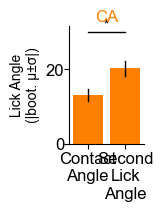

In [22]:
figName = 'Fig5_LickAngle.pdf'
nRows = 1
nCols = 1
hscalar = 1.5
vscalar = 2
figSize = [nCols*hscalar,nRows*vscalar]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "boot. μ±σ"
fontsize = 12
linewidth = 1
fig,ax=jsm.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

ylim = [0,32]
nBoot = 10000
base = np.zeros([len(anms),2])
usedAnimals = 0
for a, anm in enumerate(anms):
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    cDists = []#anmData['cDists']
    sDists = []#anmData['sDists']
    for i, mod in enumerate(['c','s']):
        azi = anmData[f'{mod}Azi']
        ele = anmData[f'{mod}Ele']
        lda = anmData['lda']
        dists = jsm.get_lickAngle(azi, ele, lda)
        if i == 0:
            cDists = dists
        else:
            sDists = dists
    phase = 'post'
    pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
    if np.sum(pMask)>0:
        pT = tracker[pMask,:]
        pME = me[pMask]
        pCD = cDists[pMask]
        pSD = sDists[pMask]
        meMask = np.logical_and(pME,pT[:,2]==5)
        
        meCDist = np.nanmean(pCD[meMask])
        secondMask = np.logical_and(pSD, pSD<0)
        me2Dist = np.nanmean(pSD[secondMask])
        
        base[a,:] = np.hstack([meCDist, me2Dist])

        usedAnimals+=1
print('nAnm:', usedAnimals)

total = np.zeros([nBoot,2])

for i in range(nBoot):
    bAnms = np.random.choice(np.arange(usedAnimals), usedAnimals)
    total[i,:] = np.nanmean(base[bAnms,:], axis = 0)


mean = np.nanmean(total, axis=0)
med = np.nanmedian(total, axis=0)
std = np.nanstd(total, axis=0, ddof = 1)
sem = std / np.sqrt(total.shape[0])
low,high = np.nanpercentile(total, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
if error == 'CI':
    mainPlot = med
    errorLow = low
    errorHigh = high
elif error == 'sem':
    mainPlot = mean
    errorLow = mean-sem
    errorHigh = mean+sem
elif error == 'std':
    mainPlot = mean
    errorHigh = mean+std
    errorLow = mean-std

pVal = np.sum(abs(total[:,1])<abs(total[:,0]))/nBoot
print(f'{pVal:.03f}')
pText = jsm.pstar(pVal,inclP = False)
colors = [(1,0.5,0),(1,0.5,0)]
for i in range(2):
    ax.bar(i, abs(mean[i]), alpha = 1, color = colors[i])
    ax.plot([i]*2, abs(np.hstack([low[i],high[i]])), color = (0,0,0),lw=linewidth)
ax.set_xticks([0,1])
ax.set_xticklabels(['Contact\nAngle', 'Second\nLick\nAngle'])
ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('Lick Angle\n(|'+errorLabel+'|)',fontsize=fontsize-2)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4) #
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #

ax.plot([0,1], [30]*2, color = (0,0,0),lw=linewidth)
ax.text(.5, 30, pText,color=(0,0,0),ha='center',va='bottom')

ax.text(0.5,ylim[1],'CA',color=colors[0],fontsize=fontsize,ha='center',va='bottom')

if PDF_export_active:
    with (PdfPages(os.path.join(figSaveDir, figName)) if PDF_export_active else contextlib.nullcontext()) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)


[1.75, 2]
dendrites CR mean: 0.075 std: 0.145 pVal: 0.300
dendrites CA mean: -0.790 std: 0.383 pVal: 0.002
dendrites AP mean: -0.101 std: 0.143 pVal: 0.185
somas CR mean: 0.860 std: 0.303 pVal: 0.002
somas CA mean: -0.106 std: 0.190 pVal: 0.303
somas AP mean: -0.127 std: 0.203 pVal: 0.172


/tmp/ipykernel_661714/535107052.py:23: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


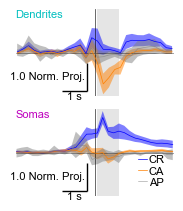

In [23]:
figName = "Fig5_MER_Projs.pdf"
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),'darkred',(0,0,0),'darkblue','darkblue',(0,0,0),'orange',(1,0,0),(1,0.5,0),(0.5,0.5,0.5)]
mod = 'CT'
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
nRows = 2
nCols = 1
hscalar = 1.75
vscalar = 1
figSize = [nCols*hscalar,nRows*vscalar]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
fontsize = 8
print(figSize)
fig,axs=jsm.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

xlim = [-3.2,3.2]
xticks = [-3,-2,-1,0,1,2,3]
window = [3.6,4.6]
xspace = [-3.6,3.6]
MER_idx = -2
MER_FC_idx = -2
MER_FA_idx = -1
allDists = {}
ylim = [0,0]
plotTtypes = [0,MER_FC_idx,MER_FA_idx]
lineStyles = ['-','-',':']
lineDashes = [(0,0),(0,0),(1,0.5)]
plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.4
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.1
plot_scaleBar['horzAdjust']=0.55
plot_scaleBar['fontsize'] = 8
plot_scaleBar['includeLabel'] = True
vertLabel = 'Norm. Proj.\n('+errorLabel+')'
vertLabel = 'Norm. Proj.'
clean = True
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
linewidth = 0.5

plotData = {}
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    data = CRCA_HHscroll[anat]['post1'][mod]['projs']['post2'] #boot, trial, time
    ax = axs[ak]
    plotData[anat] = {}
    allDists[anat] = []

    winI = [int(F*window[0]),int(F*window[1])]
    denom = (np.nanmean(abs(data[:,0,winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,MER_idx,winI[0]:winI[1]]), axis = 1))
    for t, ttype in enumerate(plotTtypes):
        trialTraces = data[:,ttype,:]/np.expand_dims(denom, axis = 1)
        # mean = np.nanmean(data[:,ttype,:], axis = 0)
        mean = np.nanmean(trialTraces, axis = 0)
        med = np.nanmedian(trialTraces, axis = 0)
        std = np.nanstd(trialTraces, axis = 0, ddof = 1)
        sem = std / np.sqrt(trialTraces.shape[0])
        low,high = np.nanpercentile(trialTraces, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        x = np.linspace(xspace[0],xspace[1],len(mean))
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        fr = x[1]-x[0]
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorHigh = mean+std
            errorLow = mean-std
        ylim[0] = np.nanmin([ylim[0],np.nanmin(errorLow)])
        ylim[1] = np.nanmax([ylim[1],np.nanmax(errorHigh)])
        winData = trialTraces[:,int(np.ceil(F*window[0])):int(np.ceil(F*window[1]))] #np.ceil
        if t == 0:
            pval = np.sum(winData.flatten()<0)/len(winData.flatten())
        else:
            pval = np.sum(winData.flatten()>0)/len(winData.flatten())
        pText = jsm.pstar(pVal,inclP = False)
        print(anat, labels[ttype], f'mean: {np.nanmean(winData):.03f}', f'std: {np.nanstd(winData):.03f}',
              f'pVal: {pval:.03f}')
        plotData[anat][t] = {'fr':fr,'x':x,'plotIdx':plotIdx, 'mainPlot':mainPlot,'errorHigh':errorHigh,'errorLow':errorLow,'pval':pval,'color':colors[ttype],'label':labels[ttype]}
        

ylim[0] = ylim[0] + np.absolute(ylim[1]-ylim[0])*-0.02
ylim[1] = ylim[1] + np.absolute(ylim[1]-ylim[0])*0.02
for ak, ax in enumerate(axs):
    anat = anatKeys[ak]
    ax.axhline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    F = frs[ak]/factors[ak]
    winF = x[int(F*window[0]):int(np.ceil(F*window[1]))]
    if winF[0]<0:
        winF = x[int(F*window[0])+1:int(np.ceil(F*window[1]))+1]
    ax.fill_between([winF[0],winF[-1]], [ylim[0]]*2, [ylim[1]]*2, color = (0,0,0), alpha = 0.1,linewidth=0,edgecolor='none')
    ax.axvline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    ax.set_ylabel(f'{niceAnatLabels[ak]}\nNorm. Proj. (a.u.)',fontsize=fontsize,labelpad=0)
    if mod == 'GO':
        alignTime = 'Go Cue'
        markers = [0,-1.25,-2.45]
    elif mod == 'LL':
        alignTime = 'Last Lick'
        markers = [0]
    else:
        alignTime = 'Contact'
        markers = [0]
    for mark in markers:
        ax.plot([mark]*2,ylim,ls='-',alpha=0.5,color=(0,0,0),linewidth=0.5)
    ax.set_xlabel(f'Time Relative to {alignTime} (s)',fontsize=fontsize,labelpad=0)
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.spines[['top','right']].set_visible(False)
    ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
for ak, anat in enumerate(anatKeys):

    for t, ttype in enumerate(plotTtypes):
        axs[ak].fill_between(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], \
                             plotData[anat][t]['errorLow'][plotData[anat][t]['plotIdx']], \
                             plotData[anat][t]['errorHigh'][plotData[anat][t]['plotIdx']], \
                             color = plotData[anat][t]['color'], alpha = 0.5,linewidth=0,edgecolor='none')
        if lineStyles[t] == '-':
            axs[ak].plot(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], plotData[anat][t]['mainPlot'][plotData[anat][t]['plotIdx']],\
                         color = plotData[anat][t]['color'], label = plotData[anat][t]['label'],lw = linewidth, ls = lineStyles[t])
        else:
            axs[ak].plot(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], plotData[anat][t]['mainPlot'][plotData[anat][t]['plotIdx']],\
                         color = plotData[anat][t]['color'], label = plotData[anat][t]['label'],lw = linewidth, ls = lineStyles[t], dashes = lineDashes[t])
            
    axs[ak].set_ylim(ylim)
    axs[ak].text(xlim[0],ylim[1], niceAnatLabels[ak], color = aColors[ak], fontsize=fontsize,ha='left',va='top')
    axs[ak].tick_params(axis='both', which='major', labelsize=fontsize) #
    if ak == 1:
        loc = 'lower right'
        axs[ak].legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
    if clean:
        axs[ak].spines[['bottom','left']].set_visible(False)
        axs[ak].set_xticks([])
        axs[ak].set_yticks([])
        axs[ak].set_xlabel('')
        axs[ak].set_ylabel('')

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)


dendrites


/tmp/ipykernel_661714/672560134.py:10: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2582 0.007  0.1776]
pVals_Corr = [0.3552 0.021  0.3552]

dendrites CR mean: 0.155 std: 0.142
dendrites CA mean: -0.761 std: 0.176
dendrites AP mean: -0.122 std: 0.102

somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.     0.4502 0.061 ]
pVals_Corr = [0.     0.4502 0.122 ]

somas CR mean: 0.872 std: 0.076
somas CA mean: -0.073 std: 0.097
somas AP mean: -0.123 std: 0.100

MultCompar Correction method = holm alpha = 0.05
pVals      = [6.000e-04 1.560e-02 9.878e-01]
pVals_Corr = [0.0018 0.0312 0.9878]


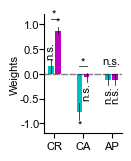

In [24]:
figName = "Fig5_Weights.pdf"
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),'darkred',(0,0,0),'darkblue','darkblue',(0,0,0),'orange',(1,0,0),(0.7,0.7,0.7),(0.31,0.31,0.31)]

nCols = 1
nRows = 1
fontsize = 8
figSize = (1.2,1.5)
fig,ax=jsm.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

MER_idx = -2
linewidth = 0.5
offsets = [2,1]
barwidth = 0.1
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
window = [3.6,4.7]
testLS = ':'
testDashes = (5,1)
testLW = 1
testColor = (0,0,0)
testAlpha = 0.5

allDists = {}
plotIdxs = [0,-2,-1]
alphas = [1,1,1]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
testLine = 0
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)
for ak, anat in enumerate(anatKeys):
    data = CRCA_HHscroll[anat]['post1'][mod]['projs']['post2'] #boot, trial, time
    F = frs[ak]/factors[ak]
    allDists[anat] = []

    x = np.linspace(-3.6,3.6,data.shape[2])
    winF = x[int(F*window[0]):int(np.ceil(F*window[1]))]
    winI = [int(F*window[0]),int(np.ceil(F*window[1]))]
    if winF[0]<0:
        winF = x[int(F*window[0])+1:int(np.ceil(F*window[1]))+1]
        winI = [int(F*window[0])+1,int(np.ceil(F*window[1]))+1]
    
    denom = (np.nanmean(abs(data[:,plotIdxs[0],winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,plotIdxs[1],winI[0]:winI[1]]), axis = 1))
    pVals = []
    for t, ttype in enumerate(plotIdxs):
        wData = np.nanmean(data[:,ttype,winI[0]:winI[1]], axis = 1)/denom

        allDists[anat].append(wData)

        mean = np.nanmean(wData)
        med = np.nanmedian(wData)
        std = np.nanstd(wData, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        
        testLine = 0
            
        tail1 = np.sum(wData<testLine)/wData.shape[0]
        tail2 = np.sum(wData>testLine)/wData.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = jsm.pstar(pVal,inclP = False)
        pVals.append(pVal)

        x = (ak/4)+t

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'
        ax.bar(x, mainPlot, width = 0.2, color = aColors[ak], alpha = alphas[ak])

        ax.plot([x,x],[errorLow,errorHigh], color = (0,0,0),lw = linewidth)

    print(anat)
    anatPCorr,pText = jsm.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)
    print('')
    for t, ttype in enumerate(plotIdxs):
        anatPTtype = anatPCorr['pvals_corrected'][t]
        ttypePText = pText[t]
        
        wData = np.nanmean(data[:,ttype,winI[0]:winI[1]], axis = 1)/denom
        mean = np.nanmean(wData)
        med = np.nanmedian(wData)
        std = np.nanstd(wData, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        
        testLine = 0
        x = (ak/4)+t

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            va='bottom'
            text_ypos = errorHigh

        if 'n.s.' in ttypePText:
            ax.text(x, text_ypos, ttypePText,fontsize=fontsize,ha='center',va=va,rotation=90)
        else:
            ax.text(x, text_ypos, ttypePText,fontsize=fontsize,ha='center',va=va,rotation=0)

        print(anat, labels[ttype], f'mean: {mean:.03f}',f'std: {std:.03f}')#, f'pval: {anatPType:03f}')
    print('')
    
ax.spines[['top','right']].set_visible(False)
ax.set_ylim([-1.2,1.2])
ys = [1.1,.15,.15]
pVals = []
for w in range(3):
    dData = allDists['dendrites'][w]
    sData = allDists['somas'][w]

    tail1 = np.sum(dData<sData)/dData.shape[0]
    tail2 = np.sum(dData>sData)/dData.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    pVals.append(pVal)

multCorr,pText = jsm.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

for w in range(3):
    y = ys[w]
    ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
    ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
ax.set_xticks(np.arange(3)+.12)
ax.set_xticklabels(['CR','CA','AP'])
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_ylabel('Weights\n('+errorLabel+')',fontsize=fontsize,labelpad=0)
ax.set_ylabel('Weights',fontsize=fontsize,labelpad=0)
ax.tick_params(axis='both', which='major', labelsize=fontsize) #
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)


# <font size="5">Rasters for paper Fig 5

In [25]:
savePath = os.path.join(DATA_DIR,'traceAlignments','fig5')  # existing directory to write the part files into
saveName = 'fig5_alignments'   # base name; '_meta' / '_<key>_<ROI_type>_<score>' suffixes are appended
extension = '.pkl'                 # '.pkl' | '.p'
verbose = True
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
big_keys = None                    # None -> every big key saved; [] -> metadata only
clusterList = None                 # None/[] -> all clusters; or list of cluster indices
ROI_clustering, cueInfo = jsm.load_ROI_clustering_reduced_split(
    savePath, saveName, ROI_type_keys=ROI_type_keys, ROI_scores=ROI_scores, big_keys=big_keys, clusterList=clusterList, extension=extension, verbose=verbose)

load_ROI_clustering_reduced_split: savePath='/export/general/pooledData/Jackson/repo_data/traceAlignments/fig5' saveName='fig5_alignments' ROI_type_keys=None ROI_scores=None big_keys=None clusterList=None trialGroupings=None
  + loaded fig5_alignments_meta.pkl  (0.006 GB)
  = cueInfo: loaded from metadata file
  + loaded fig5_alignments_clusters_dendrites_1_byPrePost_byTtype_c0.pkl  (0.039 GB)
  + loaded fig5_alignments_clusters_dendrites_1_byPrePost_byTtype_c1.pkl  (0.0 GB)
  + loaded fig5_alignments_clusters_dendrites_1_byPrePost_deltaTtypes_c0.pkl  (0.023 GB)
  + loaded fig5_alignments_clusters_dendrites_1_byPrePost_deltaTtypes_c1.pkl  (0.0 GB)
  + loaded fig5_alignments_clusters_somas_1_byPrePost_byTtype_c0.pkl  (0.05 GB)
  + loaded fig5_alignments_clusters_somas_1_byPrePost_byTtype_c1.pkl  (0.0 GB)
  + loaded fig5_alignments_clusters_somas_1_byPrePost_deltaTtypes_c0.pkl  (0.03 GB)
  + loaded fig5_alignments_clusters_somas_1_byPrePost_deltaTtypes_c1.pkl  (0.0 GB)
  = ['dendrites'][

In [26]:
batchID = 'Fig5'
figParams = {}
figSubDir = []
export_align_data = ['allTC_dffbc_decon_sp_events_MatchDx10Sx5']
setLabels = ['PostCR-MER_postCont1R']
close_all_figs = False
export_unnorm = True
export_zscored = False
export_ROI_norm = False
export_ttype_norm = False
export_groups = ['cTimes']
zoom = True
zoom_s = 6
####################################################################################################################################################################################
figParams['clean'] = True
figParams['scale_font'] = 10
# figParams['facecolors_generic']=[[0.4,0.4,0.4],[0.8,0.8,0.8],[0.6,0.6,0.6]]
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['patch_alpha'] = 0.2
figParams['colorScalar'] = 1000
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 1
figParams['cmap'] = 'inferno'
figParams['imshow_lineColor'] = (1,1,1)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['tickSpacing_fr'] = 50
##############################
figParams['clustered_data'] = 'mean'  # 'mean', 'var'
figParams['scaling_ttypes'] = ['CR','MER_postCont1R','CR-MER_postCont1R']  
figParams['scaling_be'] = ['postShift']  
figParams['traceSet_clusterGrid'] = True
figParams['traceSet_split_ttypes'] = True
figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_fillNaNs'] = True
figParams['ylim_adjust'] = [2,2]
##############################
figParams['export_ROI_type_keys'] = ['dendrites','somas']
figParams['export_ROI_scores'] = [1]
figParams['plot_data_byROI'] = 'boot_mean'
figParams['plot_data_errors'] = True
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_error_pos'] = 'boot_std' #'sem'
figParams['plot_data_error_neg'] = 'boot_std' #'sem'
figParams['traceSet_imshow_lineColor'] = (1,1,1)
figParams['traceSet_imshow_lineWidth'] = 1
figParams['traceSet_imshow_ytick_rotation'] = 0
figParams['traceSet_imshow_ytick_verticalalignment'] = 'center'
figParams['traceSet_imshow_ytick_horizontalalignment'] = 'right'
figParams['traceSet_plot_lineWidth'] = 0.5
figParams['traceSet_plot_line_alpha'] = 1
figParams['traceSet_plot_error_alpha'] = 0.3
figParams['traceSet_plot_markerSize'] = 3
figParams['traceSet_plot_full_legend'] = False
figParams['traceSet_plot_ytick_rotation'] = 0
figParams['traceSet_plot_ytick_verticalalignment'] = 'center'
figParams['traceSet_plot_ytick_horizontalalignment'] = 'right'
figParams['traceSet_alpha'] = 0.5
figParams['traceSet_fontSize'] = 8
figParams['traceSet_addSpacers'] = True
figParams['traceSet_matchCont'] = True
figParams['traceSet_clusterGrid'] = True
figParams['traceSet_addClusterLabels'] = False
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['length_s'] = 0.5
figParams['plot_scaleBar']['height_per'] = 0.3
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.6
figParams['plot_scaleBar']['horzAdjust']=0.025
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.2
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.6
figParams['im_scaleBar']['horzAdjust']=0.6
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']['vertUnit'] = '\nMasks'
figParams['im_scaleBar']['vertUnit'] = ''
figParams['im_scaleBar']['horzUnit'] = 's'
####################################################################################################################################################################################       
####################################################################################################################################################################################
####################################################################################################################################################################################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
####################################################################################################################################################################################
#########################################################################################################################################################################################################

Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}


figDir /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig5
Exporting: byPrePost_byTtype_cTimes_Post_CRvCAvAP_SP_MatchDx10Sx5_ONLY_6sZOOM.pdf

/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


allTC_dffbc_decon_sp_events_MatchDx10Sx5 dendrites 1 im_minVal = 0.000000, im_maxVal = 1.071899
                                   im_minVal_cont = 0.000000, im_maxVal_cont = 0.964709
allTC_dffbc_decon_sp_events_MatchDx10Sx5 somas 1 im_minVal = 0.000000, im_maxVal = 2.118524
                                   im_minVal_cont = 0.000000, im_maxVal_cont = 1.906672
Generating figure with size (3.0, 5.0) nRows 4 nCols 4
Adding plots TraceSet: Post_CRvCAvAP ts: 0 row: 3 col: 0 ttypes ['CR', 'MER_FC', 'MER_FA']
Adding plots TraceSet: Post_CRvCAvAP ts: 0 row: 3 col: 2 ttypes ['CR', 'MER_FC', 'MER_FA']


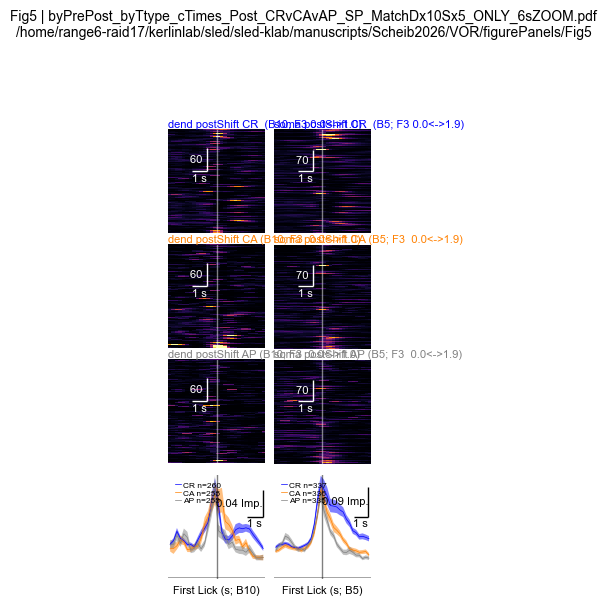

Finshed!


In [27]:
#########################################################################################################################################################################################################
aaronCmap = {}
aaronCmap['type'] = 'smooth_diverging'
aaronCmap['cmap1'] = "inferno"
aaronCmap['cmap2'] = "gray"
aaronCmap['cutoff'] = 0.85
aaronCmap['center_width'] = 0.3
aaronCmap['minVal'] = 0.5
aaronCmap['maxVal'] = 1.0

#########################################################################################################################################################################################################
figParams['export_traceSets'] = {}
####################################################################################################################################################################################
setLabel = 'Post_CRvCAvAP'
export_trialGroups = ['byPrePost_byTtype']
paramAvail = True
cg = 0
figParams['export_traceSets'][cg] = {}
###################################
cg = 0
ts = setLabel
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'PostShift CR v CA v AP'
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR','MER_FC','MER_FA']
figParams['export_traceSets'][cg][ts]['ttypeLabels'] = ['CR','CA','AP']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift','postShift','postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0,0,0]
figParams['export_traceSets'][cg][ts]['colors'] = [[0,0,1],[1,0.5,0],[0.5,0.5,0.5]]
figParams['export_traceSets'][cg][ts]['cmap'] = [(0,0,1),(1,0.5,0),(0.5,0.5,0.5),(0.5,0,1),(1,0,0)]
figParams['export_traceSets'][cg][ts]['cmap'] = [aaronCmap,aaronCmap,aaronCmap]
figParams['export_traceSets'][cg][ts]['cmap'] = ['inferno','inferno','inferno']
figParams['anatColor'] = False
figParams['anatColors'] = [(0,0.75,0.75),(0.75,0,0.75)]
##################################
figParams['scaling_ttypes'] = ['CR','MER_FC','MER_FA']  
figParams['scaling_be'] = ['postShift']  
figParams['traceSet_export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx10Sx5']
figParams['traceSet_export_align_data_label'] = ['Imp.']
figParams['traceSet_export_align_data_scaleBar_label'] = ['Imp.']
##################################
figParams['filt_trace_byROI'] = True
figParams['filt_trace_byROI_window'] = {}
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5'] = {}
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5']['dendrites'] = 3
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5']['somas'] = 3
###################################
figParams['global_im_contrast'] = False
figParams['ROI_type_im_contrast'] = True
figParams['manual_im_contrast'] = False
figParams['global_plot_contrast'] = False
figParams['ROI_type_plot_contrast'] = True
figParams['manual_plot_contrast'] = False
figParams = jsm.prep_manual_contrasts(figParams,export_groups,export_trialGroups,export_align_data)
####################################################################################################################################################################################
group = 'cTimes'
figParams['trialGrouping'] = 'byPrePost_byTtype'
figName = figParams['trialGrouping']+'_'+group+"_"+setLabel+"_SP_MatchDx10Sx5_ONLY"
figParams['traceSet_group'] = group
############################################################################################################################################
figParams['plot_data_label'] = ''
figParams['plot_stat_byROI'] = 'data'
figParams['plot_data_label_byROI'] = 'ROI Cluster Boot Mean'
figParams['plot_stat'] = 'summaryStats'
figParams['plot_data_label_full'] = "ROI Cluster Boot Mean."
figParams['plot_data_axis_label'] = 'Cluster\nBoot Mean\nSTD)'
figParams['traceSet_image_minPer'] = 0
figParams['traceSet_image_maxPer'] = 97
figParams['traceSet_minCont'] = [0]
figParams['traceSet_maxCont'] = [0.9]
figParams['traceSet_imshow_lineColor'] = (0,0,0)
figParams['traceSet_imshow_lineColor'] = (1,1,1)
figParams['traceSet_cmap'] = aaronCmap
figParams['nan_color'] = (0.2,0.2,0.2)
figParams['horzCueLineOn'] = False
figParams['horzCuePlotScalar'] = 0.02
figParams['horzCueImScalar'] = 0.01
figParams['cueInfo'] = cueInfo
figParams['traceSet_aspect'] = False
figParams['traceSet_hscalar'] = 0.75
figParams['traceSet_vscalar'] = 1.25
# figParams['traceSet_hscalar'] = 4
# figParams['traceSet_vscalar'] = 6
figParams['suptitle_margin'] = 5
figParams['trace_heightAdjust'] = 1
figParams['legendLoc'] = 'upper left'
figParams['legendBboxToAnchor'] = (0,1)
figParams['gridspec_kw']=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.02,
    hspace=0.1
)

a = 0
figParams['traceSet_byROIType_minCont'] = {}
figParams['traceSet_byROIType_maxCont'] = {}
figParams['traceSet_byROIType_minCont'][a] = {}
figParams['traceSet_byROIType_maxCont'][a] = {}

figParams['traceSet_byROIType_minCont'][a]['dendrites'] = 0
figParams['traceSet_byROIType_maxCont'][a]['dendrites'] = 0.9
figParams['traceSet_byROIType_minCont'][a]['somas'] = 0
figParams['traceSet_byROIType_maxCont'][a]['somas'] = 0.9
###################################
figParams['traceSet_split_ttypes'] = True
figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_overlay'] = False
figParams['traceSet_trace_plotScalar'] = [0]
###################################

figName = figName+figParams['plot_data_label']                            
plot_contrasts, im_contrasts = jsm.ROI_cluster_traceSets(figSaveDir,figSubDir,batchID,figName,ROI_clustering,figParams,zoom,close_all_figs,PDF_export_active=PDF_export_active)
#########################################################################################################################################################################################################
#########################################################################################################################################################################################################

figDir /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig5
Exporting: byPrePost_deltaTtypes_cTimes_Post_CRvMER_FCvMER_FA_SP_MatchDx10Sx5_ONLY_6sZOOM.pdfallTC_dffbc_decon_sp_events_MatchDx10Sx5 dendrites 1 im_minVal = -0.907243, im_maxVal = 0.290303
                                   im_minVal_cont = -0.272173, im_maxVal_cont = 0.272173
allTC_dffbc_decon_sp_events_MatchDx10Sx5 somas 1 im_minVal = -1.145589, im_maxVal = 0.867349
                                   im_minVal_cont = -0.916471, im_maxVal_cont = 0.916471
Generating figure with size (6.0, 2.4000000000000004) nRows 3 nCols 4
Adding plots TraceSet: Post_CRvMER_FCvMER_FA ts: 0 row: 2 col: 0 ttypes ['CR-MER_FC', 'CR-MER_FA']
Adding plots TraceSet: Post_CRvMER_FCvMER_FA ts: 0 row: 2 col: 2 ttypes ['CR-MER_FC', 'CR-MER_FA']


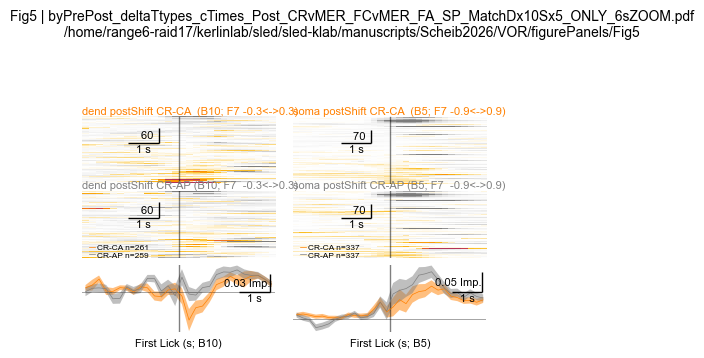

Finshed!


In [28]:

#########################################################################################################################################################################################################
aaronDiffCmap = {}
aaronDiffCmap['type'] = 'smooth_diverging'
aaronDiffCmap['cmap2'] = "gray"
aaronDiffCmap['cmap1'] = "inferno"
aaronDiffCmap['cutoff'] = 0.85
aaronDiffCmap['center_width'] = 0.3
aaronDiffCmap['minVal'] = 0.2
aaronDiffCmap['maxVal'] = 0.8
#########################################################################################################################################################################################################
setLabel = 'Post_CRvMER_FCvMER_FA'
export_trialGroups = ['byPrePost_deltaTtypes']
paramAvail = True
figParams['export_traceSets'] = {}
####################################################################################################################################################################################
cg = 0
figParams['export_traceSets'][cg] = {}
###################################
cg = 0
ts = setLabel
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'PostShift CR-MER_FC CR-MER_FA'
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR-MER_FC','CR-MER_FA']
figParams['export_traceSets'][cg][ts]['ttypeLabels'] = ['CR-CA','CR-AP']
figParams['export_traceSets'][cg][ts]['be'] = ['postShift','postShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0,0]
figParams['export_traceSets'][cg][ts]['colors'] = [[1,0.5,0],[0.5,0.5,0.5]]
figParams['export_traceSets'][cg][ts]['cmap'] = ['PRGn','PRGn']
figParams['export_traceSets'][cg][ts]['cmap'] = ['plasma','plasma']
figParams['export_traceSets'][cg][ts]['cmap'] = ['twilight_shifted','twilight_shifted']
figParams['export_traceSets'][cg][ts]['cmap'] = ['PuOr','PuOr']
figParams['export_traceSets'][cg][ts]['cmap'] = ['inferno','inferno']
figParams['export_traceSets'][cg][ts]['cmap'] = [aaronDiffCmap,aaronDiffCmap]
figParams['anatColor'] = False
figParams['anatColors'] = [(0,0.75,0.75),(0.75,0,0.75)]

###################################
figParams['scaling_ttypes'] = ['CR','MER_FC','MER_FA','CR-MER_FC','CR-MER_FA']  
figParams['scaling_be'] = ['postShift']  
figParams['traceSet_export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx10Sx5']
figParams['traceSet_export_align_data_label'] = ['Imp.']
figParams['traceSet_export_align_data_scaleBar_label'] = ['Imp.']
###################################
figParams['plot_data_byROI'] = 'boot_mean'
figParams['plot_data_errors'] = True
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_error_pos'] = 'boot_std' #'sem'
figParams['plot_data_error_neg'] = 'boot_std' #'sem'
###################################
figParams['filt_trace_byROI'] = True
figParams['filt_trace_byROI_window'] = {}
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5'] = {}
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5']['dendrites'] = 7
figParams['filt_trace_byROI_window']['allTC_dffbc_decon_sp_events_MatchDx10Sx5']['somas'] = 7
###################################
figParams['global_im_contrast'] = False
figParams['ROI_type_im_contrast'] = True
figParams['manual_im_contrast'] = False
figParams['global_plot_contrast'] = False
figParams['ROI_type_plot_contrast'] = True
figParams['manual_plot_contrast'] = False
###################################
###################################
figParams = jsm.prep_manual_contrasts(figParams,export_groups,export_trialGroups,export_align_data)
############################################################################################################################################
figParams['traceSet_imshow_lineColor'] = (0,0,0)
figParams['traceSet_cmap'] = aaronDiffCmap
figParams['nan_color'] = (0.2,0.2,0.2)
figParams['traceSet_trace_plotScalar'] = [0]
figParams['traceSet_aspect'] = False
figParams['constrained_layout'] = True
figParams['traceSet_hscalar'] = 1.5
figParams['traceSet_vscalar'] = 0.8
figParams['widthAdjust'] = 0.2
figParams['suptitle_margin'] = 5
####################################################################################################################################################################################
group = 'cTimes'
figParams['trialGrouping'] = 'byPrePost_deltaTtypes'
figName = figParams['trialGrouping']+'_'+group+"_"+setLabel+"_SP_MatchDx10Sx5_ONLY"
figParams['traceSet_group'] = group
############################################################################################################################################
figParams['plot_data_label'] = ''
figParams['plot_stat_byROI'] = 'data'
figParams['plot_data_label_byROI'] = 'ROI Cluster Boot Mean'
figParams['plot_stat'] = 'summaryStats'
figParams['plot_data_label_full'] = "ROI Cluster Boot Mean."
figParams['plot_data_axis_label'] = 'Cluster\nBoot Mean\n(STD)'
figParams['traceSet_image_minPer'] = 0
figParams['traceSet_image_maxPer'] = 90
figParams['traceSet_minCont'] = [0.2]
figParams['traceSet_maxCont'] = [0.2]
figParams['traceSet_split_ttypes'] = True

a = 0
figParams['traceSet_byROIType_minCont'] = {}
figParams['traceSet_byROIType_maxCont'] = {}
figParams['traceSet_byROIType_minCont'][a] = {}
figParams['traceSet_byROIType_maxCont'][a] = {}

figParams['traceSet_byROIType_minCont'][a]['dendrites'] = 0.3
figParams['traceSet_byROIType_maxCont'][a]['dendrites'] = 0.3
figParams['traceSet_byROIType_minCont'][a]['somas'] = 0.8
figParams['traceSet_byROIType_maxCont'][a]['somas'] = 0.8
figParams['trace_heightAdjust'] = 1
figParams['legendLoc'] = 'lower left'
figParams['legendBboxToAnchor'] = (0,1)
# figParams['manual_im_contrasts'][group][figParams['trialGrouping']][align_data]['im_maxVal_cont'] = 1
# figParams['manual_im_contrasts'][group][figParams['trialGrouping']][align_data]['im_minVal_cont'] = -1
# print(figParams['manual_im_contrasts'][group][figParams['trialGrouping']][align_data])
figName = figName+figParams['plot_data_label']                            
plot_contrasts, im_contrasts = jsm.ROI_cluster_traceSets(figSaveDir,figSubDir,batchID,figName,ROI_clustering,figParams,zoom,close_all_figs)
####################################################################################################################################################################################

# Fig5 Supplement

In [25]:
mod = 'CT'
window = [3.6,4.6]
normFactors = {}
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    winI = [int(F*window[0]),int(F*window[1])]
    normFactors[anat] = {}

    normFactors[anat]['CR-CA'] = {}

    # axesOrig = (boot x time x ROI)
    normFactors[anat]['CR-CA']['norms'] = np.linalg.norm(CRCA_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['CR-CA']['normFactor'] = np.nanmean(normFactors[anat]['CR-CA']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CA {anat} {normFactors[anat]["CR-CA"]["normFactor"]:.3f}')
    
    normFactors[anat]['CR-CL'] = {}
    # axesOrig = (boot x time x ROI)
    normFactors[anat]['CR-CL']['norms'] = np.linalg.norm(CRCL_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['CR-CL']['normFactor'] = np.nanmean(normFactors[anat]['CR-CL']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CL {anat} {normFactors[anat]["CR-CL"]["normFactor"]:.3f}')
    
    normFactors[anat]['AP-CA'] = {}
    # axesOrig = (boot x time x ROI)
    normFactors[anat]['AP-CA']['norms'] = np.linalg.norm(APCA_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['AP-CA']['normFactor'] = np.nanmean(normFactors[anat]['AP-CA']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CL {anat} {normFactors[anat]["CR-CL"]["normFactor"]:.3f}')

    normFactors[anat]['[CR-CA]/[CR-CL]'] = normFactors[anat]['CR-CA']['normFactor'] / normFactors[anat]['CR-CL']['normFactor']
    normFactors[anat]['[AP-CA]/[CR-CL]'] = normFactors[anat]['AP-CA']['normFactor'] / normFactors[anat]['CR-CL']['normFactor']

    print(f'[CR-CA]/[CR-CL] {anat} {normFactors[anat]["[CR-CA]/[CR-CL]"]:.3f}')
    print(f'[AP-CA]/[CR-CL] {anat} {normFactors[anat]["[AP-CA]/[CR-CL]"]:.3f}')


CR-CA dendrites 2.900
CR-CL dendrites 2.765
CR-CL dendrites 2.765
[CR-CA]/[CR-CL] dendrites 1.049
[AP-CA]/[CR-CL] dendrites 1.502
CR-CA somas 6.201
CR-CL somas 9.386
CR-CL somas 9.386
[CR-CA]/[CR-CL] somas 0.661
[AP-CA]/[CR-CL] somas 1.006


In [26]:
scaleTraces= True
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),(0.3,0.3,0.3),(0.7,0.2,0),(1,0.5,0),(1,0.5,0),(0.6,0.6,0.6),(1,0.5,0.5),(1,0,0),(1,0.5,0),(0.5,0.5,0.5)]
mod = 'CT'
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
fontsize = 8
xlim = [-3.2,3.2]
xticks = [-3,-2,-1,0,1,2,3]
window = [3.6,4.6]
xspace = [-3.6,3.6]
CR_idx = 0
CL_idx = 7
CA_idx = -2
AP_idx = -1
linewidth = 0.5
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
hscalar = 1.25
vscalar = 1.25
ylims = [-2.5,2.5]
yticks = [-2,-1,0,1,2]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)
nCols = 5
nRows = 2
sharex = True
sharey = True
loc = 'lower left'
clean = False
plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.75
plot_scaleBar['horzAdjust']=0.02
plot_scaleBar['fontsize'] = 8
plot_scaleBar['includeLabel'] = True
if scaleTraces:
    vertLabel = 'Scaled,\nNorm. Proj.'
    yLabel = 'Scaled, Norm.\nProj. (a.u.)'
else:
    vertLabel = 'Norm. Proj.'
    yLabel = 'Norm. Proj. (a.u.)'
manualYlim = True
reverseLeg = True

In [27]:
def plot_CD_projections(plot_scaleBar):
    nGroups = len(plotTtypes)
    delCol = 0
    if not nCols == nGroups:
        delCol=nCols-nGroups
    figSize = [nCols*hscalar,nRows*vscalar]
    fig,ax=jsm.clean_subplots(nRows,nCols,figsize=figSize,sharex=sharex,sharey=sharey,gridspec_kw=gridspec_kw,verbose=True)
    plotData = {}
    ylim = [0,0]
    for col in range(nGroups):
        plotData[col] = {}
        for ak, anat in enumerate(anatKeys):
            row=ak
            F = frs[ak]/factors[ak]
            plotData[col][anat] = {}
            winI = [int(F*window[0]),int(F*window[1])]
            if dataSource[col] == 'CRCA_HHscroll':
                data = copy.deepcopy(CRCA_HHscroll[anat]['post1'][mod]['projs']['post2']) #boot, trial, time
                if normMethod[col] == 'CR+CA':
                    denom = (np.nanmean(abs(data[:,CR_idx,winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,CA_idx,winI[0]:winI[1]]), axis = 1))
                elif normMethod[col] == 'none':
                    denom = np.ones((nBoots))
                else:
                    raise Exception("missing normMethod")
            elif dataSource[col] == 'APCA_HHscroll':
                data = copy.deepcopy(APCA_HHscroll[anat]['post1'][mod]['projs']['post2']) #boot, trial, time
                if normMethod[col] == 'AP+CA':
                    denom = (np.nanmean(abs(data[:,AP_idx,winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,CA_idx,winI[0]:winI[1]]), axis = 1))
                elif normMethod[col] == 'none':
                    denom = np.ones((nBoots))
                else:
                    raise Exception("missing normMethod")
            elif dataSource[col] == 'CRCL_HHscroll':
                data = copy.deepcopy(CRCL_HHscroll[anat]['post1'][mod]['projs']['post2']) #boot, trial, time
                if normMethod[col] == 'CR+CL':
                    denom = (np.nanmean(abs(data[:,CR_idx,winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,CL_idx,winI[0]:winI[1]]), axis = 1))
                elif normMethod[col] == 'none':
                    denom = np.ones((nBoots))
                else:
                    raise Exception("missing normMethod")
            else:
                raise Exception("missing dataSource")
            for t, ttype in enumerate(plotTtypes[col]):
                trialTraces = data[:,ttype,:]/np.expand_dims(denom, axis = 1)
                if colScaling[col]:
                    print("colScaling "+anat +" "+str(plotTtypeLabels[col])+ " x"+str(normFactors[anat][ratio]))
                    trialTraces = trialTraces * normFactors[anat][ratio]
                mean = np.nanmean(trialTraces, axis = 0)
                med = np.nanmedian(trialTraces, axis = 0)
                std = np.nanstd(trialTraces, axis = 0, ddof = 1)
                sem = std / np.sqrt(trialTraces.shape[0])
                low,high = np.nanpercentile(trialTraces, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                x = np.linspace(xspace[0],xspace[1],len(mean))
                plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
                fr = x[1]-x[0]
                if error == 'CI':
                    mainPlot = med
                    errorLow = low
                    errorHigh = high
                elif error == 'sem':
                    mainPlot = mean
                    errorLow = mean-sem
                    errorHigh = mean+sem
                elif error == 'std':
                    mainPlot = mean
                    errorHigh = mean+std
                    errorLow = mean-std
                ylim[0] = np.nanmin([ylim[0],np.nanmin(errorLow)])
                ylim[1] = np.nanmax([ylim[1],np.nanmax(errorHigh)])
                winData = trialTraces[:,int(np.ceil(F*window[0])):int(np.ceil(F*window[1]))] #np.ceil
                if t == 0:
                    pval = np.sum(winData.flatten()<0)/len(winData.flatten())
                else:
                    pval = np.sum(winData.flatten()>0)/len(winData.flatten())
                pText = jsm.pstar(pVal,inclP = False)
                print(anat, plotTtypeLabels[col][t]+"("+labels[ttype]+")", np.round(pval,3))
                plotData[col][anat][t] = {'fr':fr,'x':x,'plotIdx':plotIdx, 'mainPlot':mainPlot,'errorHigh':errorHigh,'errorLow':errorLow,'pval':pval,'color':colors[ttype],'label':plotTtypeLabels[col][t]}
            
    ylim[0] = ylim[0] + np.absolute(ylim[1]-ylim[0])*-0.02
    ylim[1] = ylim[1] + np.absolute(ylim[1]-ylim[0])*0.02
    if manualYlim:
        ylim = copy.deepcopy(ylims)
    for col in range(nGroups):
        for ak, anat in enumerate(anatKeys):
            row = ak
            ax[row,col].axhline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            F = frs[ak]/factors[ak]
            winF = x[int(F*window[0]):int(np.ceil(F*window[1]))]
            if winF[0]<0:
                winF = x[int(F*window[0])+1:int(np.ceil(F*window[1]))+1]
            ax[row,col].fill_between([winF[0],winF[-1]], [ylim[0]]*2, [ylim[1]]*2, color = (0,0,0), alpha = 0.1,linewidth=0,edgecolor='none')
            ax[row,col].axvline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            if col == 0:
                ax[row,col].set_ylabel(f'{niceAnatLabels[ak]}\n{yLabel}',fontsize=fontsize,labelpad=0)
            if mod == 'GO':
                alignTime = 'Go Cue'
                markers = [0,-1.25,-2.45]
            elif mod == 'LL':
                alignTime = 'Last Lick'
                markers = [0]
            else:
                alignTime = 'Contact'
                markers = [0]
            for mark in markers:
                ax[row,col].plot([mark]*2,ylim,ls='-',alpha=0.5,color=(0,0,0),linewidth=0.5)
            if row == nRows-1:
                ax[row,col].set_xlabel(f'Time (s; {alignTime})',fontsize=fontsize,labelpad=0)
            ax[row,col].set_xlim(xlim)
            ax[row,col].set_xticks(xticks)
            ax[row,col].set_yticks(yticks)
            ax[row,col].spines[['top','right']].set_visible(False)
            ax[row,col],plot_scaleBar = jsm.add_plot_scaleBar(ax[row,col],plot_scaleBar,(0,0,0),True,vertLabel)
        for ak, anat in enumerate(anatKeys):
            row = ak
            for t, ttype in enumerate(plotTtypes[col]):
                ax[row,col].fill_between(plotData[col][anat][t]['x'][plotData[col][anat][t]['plotIdx']], \
                                     plotData[col][anat][t]['errorLow'][plotData[col][anat][t]['plotIdx']], \
                                     plotData[col][anat][t]['errorHigh'][plotData[col][anat][t]['plotIdx']], \
                                     color = plotData[col][anat][t]['color'], alpha = 0.5,linewidth=0,edgecolor='none')
                if lineStyles[col][t] == '-':
                    ax[row,col].plot(plotData[col][anat][t]['x'][plotData[col][anat][t]['plotIdx']], plotData[col][anat][t]['mainPlot'][plotData[col][anat][t]['plotIdx']],\
                                 color = plotData[col][anat][t]['color'], label = plotData[col][anat][t]['label'],lw = linewidth, ls = lineStyles[col][t])
                else:
                    ax[row,col].plot(plotData[col][anat][t]['x'][plotData[col][anat][t]['plotIdx']], plotData[col][anat][t]['mainPlot'][plotData[col][anat][t]['plotIdx']],\
                                 color = plotData[col][anat][t]['color'], label = plotData[col][anat][t]['label'],lw = linewidth, ls = lineStyles[col][t], dashes = lineDashes[col][t])
            ax[row,col].set_ylim(ylim)
            ax[row,col].tick_params(axis='both', which='major', labelsize=fontsize) #
            ax[row,col].tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
            ax[row,col].tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
            ax[row,col].legend(frameon=False,reverse=reverseLeg,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
            if clean:
                ax[row,col].spines[['bottom','left']].set_visible(False)
                ax[row,col].set_xticks([])
                ax[row,col].set_yticks([])
                ax[row,col].set_xlabel('')
                ax[row,col].set_ylabel('')
    if delCol>0:
        col = nGroups-1
        for c in range(delCol):
            col+=1
            for row in range(nRows):
                fig.delaxes(ax[row,col])
    if PDF_export_active:
        with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
            pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
    jsm.display_clean_subplots(fig,axs)


dendrites CR(CR) 0.005
dendrites CL(CL) 0.003
somas CR(CR) 0.0
somas CL(CL) 0.024


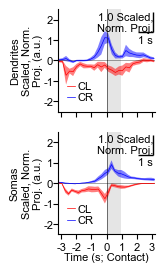

In [29]:
figName = "Fig5_CR-MER_CRCL_only.pdf"
plotTtypes = [[0,7]]
plotTtypeLabels = [['CR','CL']]
dataSource= ['CRCL_HHscroll'] #pick which source to use
normMethod = ['CR+CL']
colScaling = [False]
ratio = '[CR-CA]/[CR-CL]'
lineStyles = [['-','-']]
lineDashes = [[(0,0),(0,0)]]
#########################################################################
plot_CD_projections(plot_scaleBar)

colScaling dendrites ['AP', 'CA', 'CR'] x1.0487441
dendrites AP(AP) 0.814
colScaling dendrites ['AP', 'CA', 'CR'] x1.0487441
dendrites CA(CA) 0.002
colScaling dendrites ['AP', 'CA', 'CR'] x1.0487441
dendrites CR(CR) 0.698
colScaling somas ['AP', 'CA', 'CR'] x0.6606675
somas AP(AP) 0.827
colScaling somas ['AP', 'CA', 'CR'] x0.6606675
somas CA(CA) 0.303
colScaling somas ['AP', 'CA', 'CR'] x0.6606675
somas CR(CR) 0.998
colScaling dendrites ['CA(LC)', 'CA(RC)'] x1.0487441
dendrites CA(LC)(MER-MER) 0.996
colScaling dendrites ['CA(LC)', 'CA(RC)'] x1.0487441
dendrites CA(RC)(MER-CR) 0.001
colScaling somas ['CA(LC)', 'CA(RC)'] x0.6606675
somas CA(LC)(MER-MER) 0.901
colScaling somas ['CA(LC)', 'CA(RC)'] x0.6606675
somas CA(RC)(MER-CR) 0.304
colScaling dendrites ['AP(NC)', 'AP(LC)'] x1.0487441
dendrites AP(NC)(MER-NA) 0.995
colScaling dendrites ['AP(NC)', 'AP(LC)'] x1.0487441
dendrites AP(LC)(MER-CL) 0.13
colScaling somas ['AP(NC)', 'AP(LC)'] x0.6606675
somas AP(NC)(MER-NA) 0.806
colScaling soma

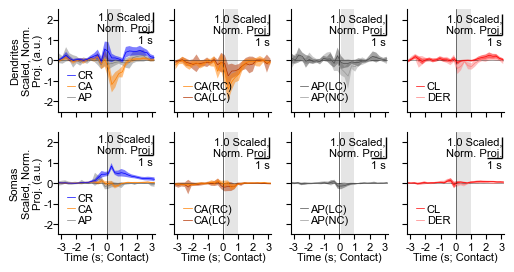

In [30]:
figName = "Fig5_CR-MER_Others.pdf"
plotTtypes = [[9,8,0],[2,3],[5,1],[6,7]]
plotTtypeLabels = [['AP','CA','CR'],['CA(LC)','CA(RC)'],['AP(NC)','AP(LC)'],['DER','CL']]
dataSource= ['CRCA_HHscroll','CRCA_HHscroll','CRCA_HHscroll','CRCA_HHscroll'] #pick which source to use
normMethod = ['CR+CA','CR+CA','CR+CA','CR+CA']
colScaling = [True,True,True,True]
ratio = '[CR-CA]/[CR-CL]'
lineStyles = [['-','-','-'],['-','-'],['-','-'],['-','-']]
lineDashes = [[(0,0),(0,0),(0,0)],[(0,0),(0,0)],[(0,0),(0,0)],[(0,0),(0,0)]]
#########################################################################
plot_CD_projections(plot_scaleBar)

### raw trials correlation

In [37]:
allRawImgs = {}
ttype1 = 0
ttype2 = 8

# SWITCH TO CA

for mod in ['CT']:#,'SL']:
    allRawImgs[mod] = {}
    for ak, anat in enumerate(anatKeys):
        aImgs = []
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            A = megaTsepsHH["post1"][f'err{mod}'][anat][ttype1,:,:,i]
            B = megaTsepsHH["post2"][f'err{mod}'][anat][ttype2,:,:,i]
            nTime = A.shape[0] #time, roi
            halfTime = nTime/2
            mat = np.zeros([nTime, nTime])
            for i in range(nTime):
                for j in range(nTime):
                    mat[i,j] = pearsonr(A[i,:], B[j,:])[0]
            aImgs.append(mat)
        allRawImgs[mod][anat] = np.dstack(aImgs)
        


CT dendrites:   0%|          | 0/10000 [00:00<?, ?it/s]

CT somas:   0%|          | 0/10000 [00:00<?, ?it/s]

In [38]:
allRawImgs = {}
ttype1 = 0
ttype2 = 8
for mod in ['CT']:#,'SL']:
    allRawImgs[mod] = {}
    for ak, anat in enumerate(anatKeys):
        aImgs = []
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            R=np.corrcoef(CRCA_HHscroll[anat]['post1'][mod]['axesOrig'][i,:,:],
                          CRCA_HHscroll[anat]['post2'][mod]['axesOrig'][i,:,:])
            hp = int(R.shape[0]/2)
            R = R[hp:,:hp]
            aImgs.append(R)
        allRawImgs[mod][anat] = np.dstack(aImgs)


CT dendrites:   0%|          | 0/10000 [00:00<?, ?it/s]

CT somas:   0%|          | 0/10000 [00:00<?, ?it/s]

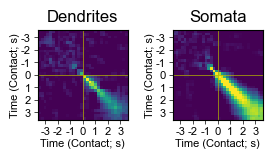

In [39]:
fontsize = 8
figsize=[3,1]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.0,
    hspace=0.8
)
fig,axs=jsm.clean_subplots(1,2,figsize=figsize,sharex=False,sharey=False,gridspec_kw=gridspec_kw)
axs = np.squeeze(axs)
tmin, tmax = -3.6, 3.6
cmin = 0
cmax = 0.75
ticks = [-3,-2,-1,0,1,2,3]
ColorScalar = 1000
rcmap = [(1,1,1),(0,0,1)]
rcmap = 'viridis'
cmap,tempRGB,tempBGR = jsm.generate_cmap(rcmap,ColorScalar,cmap_name='cmap')
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somata']
for m, mod in enumerate(allRawImgs.keys()):
    if mod == 'CT':
        modLabel = 'Contact'
    else:
        modLabel = 'Second Contact'
    for ak, anat in enumerate(anatKeys):
        ax = axs[ak]
        ax.set_title(f'{niceAnatLabels[ak]}')
        img = np.nanmedian(allRawImgs[mod][anat], axis = 2)
        img_RGB = jsm.convert2RGB(img,cmin,cmax,cmap,ColorScalar)
        im = ax.imshow(img_RGB, extent=[tmin,tmax,tmax,tmin],interpolation='none')
        ax.axvline(0, color = (180/255,180/255,0), linestyle = '-', lw = 0.5, alpha = 1)
        ax.axhline(0, color = (180/255,180/255,0), linestyle = '-', lw = 0.5, alpha = 1)
        for item in [ax.set_xlabel]:
            item(f'Time ({modLabel}; s)',fontsize=fontsize, labelpad=1)
        ax.set_ylabel(f'Time ({modLabel}; s)',fontsize=fontsize, labelpad=0.5)
        ax.set_xlim([tmin, tmax])
        ax.set_ylim([tmax,tmin])
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.tick_params(axis='both', which='major', labelsize=fontsize) 
        ax.tick_params(axis='x', which='major', width=0.5, length=3, labelsize=fontsize, pad=2)
        ax.tick_params(axis='x', which='minor', width=0.5, length=1.5, labelsize=fontsize, pad=2)
        ax.tick_params(axis='y', which='major', width=0.5, length=3, labelsize=fontsize, pad=2)
        ax.tick_params(axis='y', which='minor', width=0.5, length=1.5, labelsize=fontsize, pad=2)
figName = 'MERSupp_CRCA_Correlation.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)
